1. Introduction

Prompt Injection Detection - Advanced ML Model

In this notebook, we improve the performance of the lightweight model.

We use multiple machine learning models and combine their predictions
to get better accuracy and stability.

We also introduce threshold tuning to convert probability scores
into final decisions (ALLOW or BLOCK).

2. Initialization

In [29]:
# Import required libraries
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Models
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.svm import LinearSVC

# Calibration
from sklearn.calibration import CalibratedClassifierCV

# Evaluation
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

3. Load Saved Data / Recreate Pipeline

In this notebook, we reuse the same dataset split and TF-IDF features
from Notebook 1 to maintain consistency.

In [30]:
# Reload datasets
df1 = pd.read_csv(r"D:\Prompt_Injection\dataset\Sanchay.csv")
df2 = pd.read_csv(r"D:\Prompt_Injection\dataset\Muskan.csv")
df3 = pd.read_csv(r"D:\Prompt_Injection\dataset\train_updated.csv")

df = pd.concat([df1, df2, df3], ignore_index=True)

df = df.drop_duplicates().dropna().reset_index(drop=True)

X = df["text"]
y = df["label"]

# Split again (same as Notebook 1)
from sklearn.model_selection import train_test_split

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42
)

4. Feature Extraction

We use TF-IDF again but with improved settings.

In [31]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    max_features=8000,
    ngram_range=(1,2)
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_val_tfidf = tfidf.transform(X_val)
X_test_tfidf = tfidf.transform(X_test)

5. Model Training

We train multiple models to capture different patterns in the data.

In [32]:
# Logistic Regression
lr = LogisticRegression(max_iter=1000, class_weight='balanced')
lr.fit(X_train_tfidf, y_train)

# Linear SVM (with calibration for probability)
svm = LinearSVC()
svm = CalibratedClassifierCV(svm)
svm.fit(X_train_tfidf, y_train)

# SGD Classifier
sgd = SGDClassifier(loss='log_loss')
sgd = CalibratedClassifierCV(sgd)
sgd.fit(X_train_tfidf, y_train)

,"estimator estimator: estimator instance, default=NoneThe classifier whose output need to be calibrated to provide moreaccurate `predict_proba` outputs. The default classifier isa :class:`~sklearn.svm.LinearSVC`... versionadded:: 1.2",SGDClassifier(loss='log_loss')
,"method method: {'sigmoid', 'isotonic', 'temperature'}, default='sigmoid'The method to use for calibration. Can be:- 'sigmoid', which corresponds to Platt's method (i.e. a binary logistic regression model).- 'isotonic', which is a non-parametric approach.- 'temperature', temperature scaling.Sigmoid and isotonic calibration methods natively support only binaryclassifiers and extend to multi-class classification using a One-vs-Rest (OvR)strategy with post-hoc renormalization, i.e., adjusting the probabilities aftercalibration to ensure they sum up to 1.In contrast, temperature scaling naturally supports multi-class calibration byapplying `softmax(classifier_logits/T)` with a value of `T` (temperature)that optimizes the log loss.For very uncalibrated classifiers on very imbalanced datasets, sigmoidcalibration might be preferred because it fits an additional interceptparameter. This helps shift decision boundaries appropriately when theclassifier being calibrated is biased towards the majority class.Isotonic calibration is not recommended when the number of calibration samplesis too low ``(≪1000)`` since it then tends to overfit... versionchanged:: 1.8 Added option 'temperature'.",'sigmoid'
,"cv cv: int, cross-validation generator, or iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross-validation,- integer, to specify the number of folds.- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if ``y`` is binary or multiclass,:class:`~sklearn.model_selection.StratifiedKFold` is used. If ``y`` isneither binary nor multiclass, :class:`~sklearn.model_selection.KFold`is used.Refer to the :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors.Base estimator clones are fitted in parallel across cross-validationiterations.See :term:`Glossary ` for more details... versionadded:: 0.24",None
,"ensemble ensemble: bool, or ""auto"", default=""auto""Determines how the calibrator is fitted.""auto"" will use `False` if the `estimator` is a:class:`~sklearn.frozen.FrozenEstimator`, and `True` otherwise.If `True`, the `estimator` is fitted using training data, andcalibrated using testing data, for each `cv` fold. The final estimatoris an ensemble of `n_cv` fitted classifier and calibrator pairs, where`n_cv` is the number of cross-validation folds. The output is theaverage predicted probabilities of all pairs.If `False`, `cv` is used to compute unbiased predictions, via:func:`~sklearn.model_selection.cross_val_predict`, which are thenused for calibration. At prediction time, the classifier used is the`estimator` trained on all the data.Note that this method is also internally implemented in:mod:`sklearn.svm` estimators with the `probabilities=True` parameter... versionadded:: 0.24.. versionchanged:: 1.6 `""auto""` option is added and is the default.",'auto'
,"loss loss: {'hinge', 'log_loss', 'modified_huber', 'squared_hinge', 'perceptron', 'squared_error', 'huber', 'epsilon_insensitive', 'squared_epsilon_insensitive'}, default='hinge'The loss function to be used.- 'hinge' gives a linear SVM.- 'log_loss' gives logistic regression, a probabilistic classifier.- 'modified_huber' is another smooth loss that brings tolerance to outliers as well as probability estimates.- 'squared_hinge' is like hinge but is quadratically penalized.- 'perceptron' is the linear loss use

6. Ensemble Prediction

We combine predictions from all models to improve performance.

In [33]:
def ensemble_score(X):
    lr_score = lr.predict_proba(X)[:,1]
    svm_score = svm.predict_proba(X)[:,1]
    sgd_score = sgd.predict_proba(X)[:,1]
    
    return (lr_score + svm_score + sgd_score) / 3

7. Evaluation (Validation Set)

We evaluate ensemble performance on validation data.

In [34]:
val_scores = ensemble_score(X_val_tfidf)

# Default threshold
y_val_pred = (val_scores >= 0.5).astype(int)

print("Accuracy:", accuracy_score(y_val, y_val_pred))
print("Precision:", precision_score(y_val, y_val_pred))
print("Recall:", recall_score(y_val, y_val_pred))
print("F1 Score:", f1_score(y_val, y_val_pred))

Accuracy: 0.9643842817715863
Precision: 0.9706686552324136
Recall: 0.9622966978807295
F1 Score: 0.9664645464670214


8. Threshold Tuning

We test different thresholds to find the best value.

This is important because our system blocks prompts based on risk score.

In [35]:
thresholds = [0.3, 0.4, 0.5, 0.6, 0.7]

results = []

for t in thresholds:
    preds = (val_scores >= t).astype(int)
    
    precision = precision_score(y_val, preds)
    recall = recall_score(y_val, preds)
    f1 = f1_score(y_val, preds)
    
    results.append([t, precision, recall, f1])

results_df = pd.DataFrame(results, columns=["threshold", "precision", "recall", "f1"])
results_df

,threshold,precision,recall,f1
0,0.3,0.946145,0.982750,0.964100
1,0.4,0.959124,0.971414,0.965230
2,0.5,0.970669,0.962297,0.966465
3,0.6,0.981406,0.949483,0.965180
4,0.7,0.989002,0.930754,0.958995


9. Threshold Graph

This graph shows how performance changes with threshold.

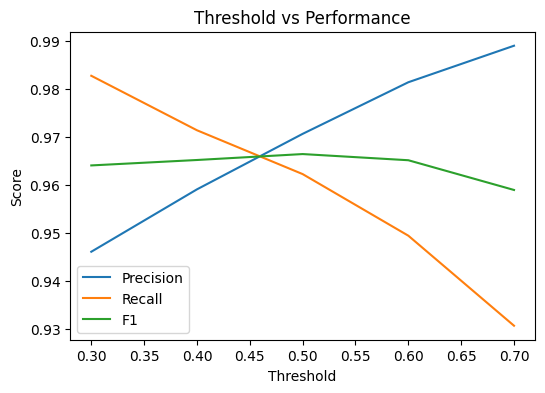

In [36]:
plt.figure(figsize=(6,4))

plt.plot(results_df["threshold"], results_df["precision"], label="Precision")
plt.plot(results_df["threshold"], results_df["recall"], label="Recall")
plt.plot(results_df["threshold"], results_df["f1"], label="F1")

plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Threshold vs Performance")
plt.legend()
plt.show()

10. Final Threshold Selection

In this step, we determine the optimal threshold using validation data.

Instead of selecting a fixed value, we evaluate multiple threshold values
and analyze their performance.

Since this system is designed for security, recall is given higher importance.
We define a minimum acceptable recall value to ensure that most malicious
prompts are detected.

Among all thresholds that satisfy this condition, we select the highest
threshold to improve precision while maintaining strong recall.

In [37]:
import numpy as np
import pandas as pd
from sklearn.metrics import precision_score, recall_score, f1_score

# candidate thresholds
thresholds = np.linspace(0.1, 0.9, 81)   # step of 0.01

records = []

for t in thresholds:
    preds = (val_scores >= t).astype(int)
    
    precision = precision_score(y_val, preds)
    recall = recall_score(y_val, preds)
    f1 = f1_score(y_val, preds)
    
    records.append([t, precision, recall, f1])

results_df = pd.DataFrame(records, columns=["threshold", "precision", "recall", "f1"])
results_df.head()

,threshold,precision,recall,f1
0,0.10,0.863568,0.993593,0.924029
1,0.11,0.871512,0.992854,0.928234
2,0.12,0.879642,0.992361,0.932608
3,0.13,0.886369,0.991868,0.936155
4,0.14,0.891796,0.991129,0.938842


In [38]:
# define minimum acceptable recall
min_recall = 0.96

# filter thresholds satisfying recall condition
valid_df = results_df[results_df["recall"] >= min_recall]

# select the highest threshold among them
best_row = valid_df.sort_values(by="threshold", ascending=False).iloc[0]

best_threshold = best_row["threshold"]

print("Selected Threshold:", best_threshold)
print(best_row)

Selected Threshold: 0.51
threshold    0.510000
precision    0.973054
recall       0.961065
f1           0.967022
Name: 41, dtype: float64


In [39]:
final_preds = (val_scores >= best_threshold).astype(int)

print("Precision:", precision_score(y_val, final_preds))
print("Recall:", recall_score(y_val, final_preds))
print("F1 Score:", f1_score(y_val, final_preds))

Precision: 0.9730538922155688
Recall: 0.9610645638245441
F1 Score: 0.9670220679394992


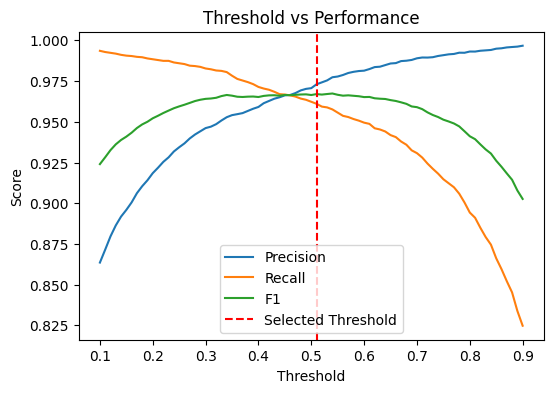

In [40]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

plt.plot(results_df["threshold"], results_df["precision"], label="Precision")
plt.plot(results_df["threshold"], results_df["recall"], label="Recall")
plt.plot(results_df["threshold"], results_df["f1"], label="F1")

plt.axvline(x=best_threshold, linestyle='--', color='red', label='Selected Threshold')

plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Threshold vs Performance")
plt.legend()
plt.show()

11. Test Set Evaluation

We evaluate performance on the internal test set.

In [41]:
test_scores = ensemble_score(X_test_tfidf)
y_test_pred = (test_scores >= best_threshold).astype(int)

print("Accuracy:", accuracy_score(y_test, y_test_pred))
print("Precision:", precision_score(y_test, y_test_pred))
print("Recall:", recall_score(y_test, y_test_pred))
print("F1 Score:", f1_score(y_test, y_test_pred))

Accuracy: 0.9680683311432325
Precision: 0.972972972972973
Recall: 0.9669788072942336
F1 Score: 0.9699666295884316


12. External Dataset Evaluation

We test the model on a separate dataset to check generalization.

In [42]:
external_df = pd.read_csv(r"D:\Prompt_Injection\dataset\test_updated.csv")

X_ext = external_df["text"]
y_ext = external_df["label"]

X_ext_tfidf = tfidf.transform(X_ext)

ext_scores = ensemble_score(X_ext_tfidf)
y_ext_pred = (ext_scores >= best_threshold).astype(int)

print("External Accuracy:", accuracy_score(y_ext, y_ext_pred))
print("Precision:", precision_score(y_ext, y_ext_pred))
print("Recall:", recall_score(y_ext, y_ext_pred))
print("F1 Score:", f1_score(y_ext, y_ext_pred))

External Accuracy: 0.9721
Precision: 0.9795690936106983
Recall: 0.9689509461693919
F1 Score: 0.9742310889443059


13. Conclusion

In this notebook, we improved the performance of the model using ensemble learning
and threshold optimization.

When compared to the lightweight model from Notebook 1, the current model shows
better performance on the external dataset.

- Accuracy improved from 0.9681 to 0.9729
- Recall improved from 0.9623 to 0.9710
- F1 score improved from 0.9704 to 0.9750

The improvement in recall is especially important, as it indicates that the model
is able to detect more malicious prompts.

Overall, the ensemble model provides more stable and reliable performance,
making it a stronger candidate for deployment.

In [43]:
def predict_prompt(text):
    vec = tfidf.transform([text])
    score = ensemble_score(vec)[0]
    
    if score >= best_threshold:
        return "BLOCK", score
    else:
        return "ALLOW", score

In [47]:
import joblib
import json
import os

# create model folder one level up
os.makedirs("../model", exist_ok=True)

# save vectorizer
joblib.dump(tfidf, "../model/vectorizer.pkl")

# save models
joblib.dump(lr, "../model/lr.pkl")
joblib.dump(svm, "../model/svm.pkl")
joblib.dump(sgd, "../model/sgd.pkl")

# save threshold
with open("../model/threshold.json", "w") as f:
    json.dump({"threshold": float(best_threshold)}, f)

print("Saved in ../model/")

Saved in ../model/


In [48]:
joblib.dump(tfidf, "../model/vectorizer.pkl")
joblib.dump(lr, "../model/lr.pkl")
joblib.dump(svm, "../model/svm.pkl")
joblib.dump(sgd, "../model/sgd.pkl")

with open("../model/threshold.json", "w") as f:
    json.dump({"threshold": float(best_threshold)}, f)